<a href="https://colab.research.google.com/github/mohitkumawat5797/sukshma-a-small-LLM/blob/main/sukshma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers datasets accelerate

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!nvidia-smi

Tue Sep 15 14:03:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
"""
Pretrain a LLM-135M-style model from scratch on English text (FineWeb-Edu),
streamed directly from the Hugging Face Hub. Designed for Google Colab, single
GPU (T4/A100), with Drive-based checkpointing so you can resume across
disconnected sessions or a different Colab account.

=== Colab setup (run once per session) ===
    !pip install -q transformers datasets accelerate
    from google.colab import drive
    drive.mount('/content/drive')

Then run this script (or paste it cell by cell). If resuming on a new
account: just make sure /content/drive/MyDrive/smol_llm/checkpoints
is reachable (copy the checkpoint folder into the new account's Drive,
or share the folder and add a shortcut).
"""

import os
import math
import glob
import torch
import torch.nn.functional as F
from torch.utils.data import IterableDataset, DataLoader
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    LlamaConfig,
    LlamaForCausalLM,
    get_cosine_schedule_with_warmup,
)

In [5]:
# ------------------------------------------------------------------
# 0. CONFIG — tune these to your GPU / time budget
# ------------------------------------------------------------------
DRIVE_ROOT = "/content/drive/MyDrive/smol_llm"
CKPT_DIR = f"{DRIVE_ROOT}/checkpoints"

In [6]:
HF_DATASET_NAME = "HuggingFaceFW/fineweb-edu"
HF_DATASET_CONFIG = "sample-10BT"

TOKENIZER_PATH = "HuggingFaceTB/SmolLM2-135M"

SEQ_LEN = 1024
MICRO_BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 32
MAX_STEPS = 5000          # bumped from 500 -- 500 steps is only a smoke test,
                           # not enough tokens to get coherent output. Raise
                           # further if you have the GPU time.
WARMUP_STEPS = 50
PEAK_LR = 6e-4
MIN_LR = 6e-5
WEIGHT_DECAY = 0.1
LOG_EVERY = 20

# --- time-based checkpointing -----------------------------------------
# Colab sessions can disconnect at any point, so we save on a wall-clock
# timer instead of (or in addition to) a step count -- this guarantees
# you never lose more than ~SAVE_EVERY_SECONDS of progress regardless of
# how fast/slow each step is.
SAVE_EVERY_SECONDS = 30 * 60   # 30 minutes
SAVE_EVERY_STEPS_MAX = 200     # safety net: force a save at least this often
                                # even if 30 min hasn't passed (e.g. steps
                                # are unexpectedly fast and you want more
                                # frequent restore points)
KEEP_LAST_N_CKPTS = 3           # how many checkpoints to retain on Drive

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FP16 = True

os.makedirs(CKPT_DIR, exist_ok=True)

In [7]:
# ------------------------------------------------------------------
# 1. TOKENIZER
# ------------------------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_PATH)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# We pack raw token ids into fixed-length blocks ourselves (see the
# PackedStreamingDataset below), so the tokenizer's own max-length
# truncation doesn't apply here. Without this, .encode() on long
# documents spams "sequence length longer than the specified maximum"
# warnings for every long doc in the stream.
tokenizer.model_max_length = int(1e9)

config.json:   0%|          | 0.00/704 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.66k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

In [8]:
# ------------------------------------------------------------------
# 2. MODEL — LLM-135M architecture, RANDOMLY INITIALIZED (not pretrained)
# ------------------------------------------------------------------
config = LlamaConfig(
    vocab_size=tokenizer.vocab_size,
    hidden_size=576,
    intermediate_size=1536,
    num_hidden_layers=30,
    num_attention_heads=9,
    num_key_value_heads=3,        # grouped-query attention, matches this model
    max_position_embeddings=SEQ_LEN,
    rms_norm_eps=1e-5,
    rope_theta=10000.0,
    tie_word_embeddings=True,     # This model ties input/output embeddings — saves params
    pad_token_id=tokenizer.pad_token_id,
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id,
)
model = LlamaForCausalLM(config)  # fresh random weights — this IS "from scratch"
model.config.use_cache = False    # must be off when using gradient checkpointing
model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})  # trades compute for VRAM, important on T4
model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model initialized with {n_params/1e6:.1f}M parameters")

Model initialized with 134.5M parameters


In [9]:
!pip install -q torchinfo
from torchinfo import summary

summary(
    model,
    input_size=(1, SEQ_LEN),
    dtypes=[torch.long],
    col_names=["input_size", "output_size", "num_params"],
    depth=4,
)

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #
LlamaForCausalLM                                   [1, 1024]                 [1, 1024, 49152]          --
├─LlamaModel: 1-1                                  --                        [1, 1024, 576]            --
│    └─Embedding: 2-1                              [1, 1024]                 [1, 1024, 576]            28,311,552
│    └─LlamaRotaryEmbedding: 2-2                   [1, 1024, 576]            [1, 1024, 64]             --
│    └─ModuleList: 2-3                             --                        --                        --
│    │    └─LlamaDecoderLayer: 3-1                 [1, 1024, 576]            [1, 1024, 576]            --
│    │    │    └─LlamaRMSNorm: 4-1                 [1, 1024, 576]            [1, 1024, 576]            576
│    │    │    └─LlamaAttention: 4-2               --                        [1, 1024, 576]            884,736
│    │    │    └─LlamaRMSNo

In [10]:
# ------------------------------------------------------------------
# 3. RESUME FROM CHECKPOINT IF ONE EXISTS (critical for Colab) — done
#    before building the dataset so we know how far into the stream
#    to skip on restart.
# ------------------------------------------------------------------
start_step = 0
latest_ckpt = sorted(glob.glob(f"{CKPT_DIR}/step_*.pt"))
if latest_ckpt:
    ckpt = torch.load(latest_ckpt[-1], map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    start_step = ckpt["step"]
    print(f"Resumed from {latest_ckpt[-1]} at step {start_step}")

# rough number of examples to skip so we don't always retrain on the same
# opening slice of FineWeb-Edu after a restart (approximate is fine here)
approx_examples_seen = start_step * MICRO_BATCH_SIZE * GRAD_ACCUM_STEPS

Resumed from /content/drive/MyDrive/smol_llm/checkpoints/step_000288.pt at step 288


In [11]:
# ------------------------------------------------------------------
# 4. DATA — stream FineWeb-Edu and pack into fixed-length blocks
# ------------------------------------------------------------------
from itertools import islice

class PackedStreamingDataset(IterableDataset):
    def __init__(self, hf_dataset_name, hf_dataset_config, tokenizer, seq_len, resume_skip=0):
        self.hf_dataset_name = hf_dataset_name
        self.hf_dataset_config = hf_dataset_config
        self.tokenizer = tokenizer
        self.seq_len = seq_len
        self.resume_skip = resume_skip

    def __iter__(self):
        ds = load_dataset(
            self.hf_dataset_name, self.hf_dataset_config, split="train", streaming=True
        )
        # Faster iterator skipping without full pipeline blocking
        stream_iter = iter(ds)
        if self.resume_skip > 0:
            stream_iter = islice(stream_iter, self.resume_skip, None)

        buffer = []
        for example in stream_iter:
            text = example.get("text", "")
            if not text:
                continue
            ids = self.tokenizer.encode(text + self.tokenizer.eos_token)
            buffer.extend(ids)
            while len(buffer) >= self.seq_len:
                block = buffer[: self.seq_len]
                buffer = buffer[self.seq_len :]
                yield torch.tensor(block, dtype=torch.long)


dataset = PackedStreamingDataset(
    HF_DATASET_NAME, HF_DATASET_CONFIG, tokenizer, SEQ_LEN, resume_skip=approx_examples_seen
)
loader = DataLoader(dataset, batch_size=MICRO_BATCH_SIZE, drop_last=True)

In [12]:
# ------------------------------------------------------------------
# 5. OPTIMIZER + SCHEDULER
# ------------------------------------------------------------------
optimizer = torch.optim.AdamW(
    model.parameters(), lr=PEAK_LR, betas=(0.9, 0.95), weight_decay=WEIGHT_DECAY
)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=MAX_STEPS
)
if latest_ckpt:
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])

# T4 GPUs don't have bf16 tensor cores — use fp16 + GradScaler instead.
# If you're on an A100 (Colab Pro), switch to bf16 and drop the scaler.
scaler = torch.amp.GradScaler(DEVICE)

In [13]:
# ------------------------------------------------------------------
# 6. TRAINING LOOP -- with live progress bar (tqdm) + loss/accuracy/ppl
# ------------------------------------------------------------------
# pip install tqdm  (already ships with most Colab images, but just in case)
import time
from tqdm.auto import tqdm

# --- "Virtual epoch" setting ------------------------------------------------
# There's no real epoch here because the dataset is an infinite stream from
# FineWeb-Edu, not a fixed-size dataset you loop over. This is just a display
# convenience: every STEPS_PER_EPOCH steps, the epoch counter ticks up by 1.
STEPS_PER_EPOCH = 500

# --- held-out eval batches --------------------------------------------------
# Grab a small fixed set of batches ONCE, before training starts, and never
# train on them. Re-using the same batches every eval gives you a comparable
# number across steps so you can tell "learning" apart from "got an easy batch".
N_EVAL_BATCHES = 5
eval_batches = []
_eval_iter = iter(loader)
for _ in range(N_EVAL_BATCHES):
    eval_batches.append(next(_eval_iter).to(DEVICE))

@torch.no_grad()
def run_eval():
    model.eval()
    losses = []
    for b in eval_batches:
        with torch.autocast(device_type=DEVICE, dtype=torch.float16, enabled=(DEVICE == "cuda")):
            out = model(input_ids=b, labels=b)
        losses.append(out.loss.item())
    model.train()
    return sum(losses) / len(losses)

model.train()
step = start_step
data_iter = iter(loader)

if "loss_history" not in globals():
    loss_history = []   # list of (step, loss, ppl, accuracy, eval_loss)

# CSV log lives outside the .pt checkpoints so you can plot progress
# without loading a full model checkpoint.
log_path = f"{CKPT_DIR}/loss_log.csv"
if not os.path.exists(log_path):
    with open(log_path, "w") as f:
        f.write("step,loss,ppl,accuracy,eval_loss,lr,elapsed_sec\n")

pbar = tqdm(total=MAX_STEPS, initial=start_step, desc="training", unit="step")

run_start_time = time.time()
last_save_time = time.time()   # resets each session -- fine, since the point
                                # is "don't lose more than 30 min of THIS run"
last_save_step = step

while step < MAX_STEPS:
    optimizer.zero_grad()
    accumulated_loss = 0.0
    correct = 0
    total = 0

    for _ in range(GRAD_ACCUM_STEPS):
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            batch = next(data_iter)

        batch = batch.to(DEVICE)
        inputs, labels = batch, batch.clone()  # standard causal LM: predict next token

        with torch.autocast(device_type=DEVICE, dtype=torch.float16, enabled=(DEVICE == "cuda")):
            out = model(input_ids=inputs, labels=labels)
            loss = out.loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()
        accumulated_loss += loss.item()

        # --- next-token accuracy (top-1) -----------------------------------
        with torch.no_grad():
            preds = out.logits[:, :-1, :].argmax(dim=-1)
            targets = labels[:, 1:]
            correct += (preds == targets).sum().item()
            total += targets.numel()

    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    # only advance the LR schedule if the optimizer actually stepped
    # (scaler.step() silently skips on inf/nan grads, common early on)
    old_scale = scaler.get_scale()
    scaler.step(optimizer)
    scaler.update()
    new_scale = scaler.get_scale()
    if new_scale >= old_scale:
        scheduler.step()

    step += 1
    accuracy = correct / max(total, 1)
    ppl = math.exp(min(accumulated_loss, 20))  # cap to avoid overflow early on
    epoch = step // STEPS_PER_EPOCH  # virtual, display-only

    pbar.set_postfix({
        "epoch": epoch,
        "loss": f"{accumulated_loss:.3f}",
        "acc": f"{accuracy*100:.1f}%",
        "ppl": f"{ppl:.1f}",
        "lr": f"{scheduler.get_last_lr()[0]:.1e}",
    })
    pbar.update(1)

    elapsed_since_save = time.time() - last_save_time
    should_save = (
        elapsed_since_save >= SAVE_EVERY_SECONDS
        or step - last_save_step >= SAVE_EVERY_STEPS_MAX
        or step == MAX_STEPS
    )

    if step % LOG_EVERY == 0 or should_save:
        eval_loss = run_eval() if should_save else None
        loss_history.append((step, accumulated_loss, ppl, accuracy, eval_loss))
        with open(log_path, "a") as f:
            f.write(
                f"{step},{accumulated_loss:.4f},{ppl:.4f},{accuracy:.4f},"
                f"{'' if eval_loss is None else f'{eval_loss:.4f}'},"
                f"{scheduler.get_last_lr()[0]:.6e},{time.time() - run_start_time:.1f}\n"
            )
            if eval_loss is not None:
                pbar.write(f"[step {step}] eval_loss={eval_loss:.4f}  eval_ppl={math.exp(min(eval_loss,20)):.1f}")

    if should_save:
        ckpt_path = f"{CKPT_DIR}/step_{step:06d}.pt"
        torch.save(
            {
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "step": step,
                "loss_history": loss_history,
            },
            ckpt_path,
        )
        pbar.write(f"[step {step}] checkpoint saved -> {ckpt_path}  ({elapsed_since_save/60:.1f} min since last save)")

        old = sorted(glob.glob(f"{CKPT_DIR}/step_*.pt"))[:-KEEP_LAST_N_CKPTS]
        for f in old:
            os.remove(f)

        last_save_time = time.time()
        last_save_step = step

pbar.close()

README.md:   0%|          | 0.00/26.4k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

training:   6%|5         | 288/5000 [00:00<?, ?step/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

KeyboardInterrupt: 

['step', 'loss', 'ppl', 'accuracy', 'eval_loss', 'lr', 'elapsed_sec']
    step  eval_loss
0     20        NaN
1     40        NaN
2     42     7.5776
3     60        NaN
4     80        NaN
5     84     7.0717
6    100        NaN
7    120        NaN
8    125     6.6060
9    140        NaN
10   160        NaN
11   166     6.3313
12   180        NaN
13   200        NaN
14   207     6.1251
15   220        NaN
16   240        NaN
17   248     5.9585
18   260        NaN
19   280        NaN
20   288     5.7589
21   300        NaN
22   320        NaN


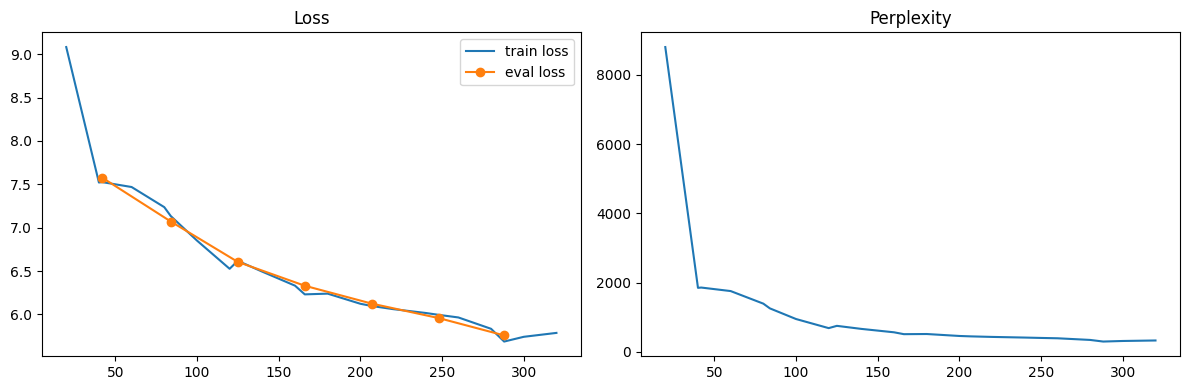

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(f"{CKPT_DIR}/loss_log.csv")
print(df.columns.tolist())          # sanity check column names
print(df[["step", "eval_loss"]])    # sanity check values

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(df["step"], df["loss"], label="train loss")

eval_df = df.dropna(subset=["eval_loss"])  # drop rows where eval wasn't run
if not eval_df.empty:
    ax[0].plot(eval_df["step"], eval_df["eval_loss"], label="eval loss", marker="o")
else:
    print("⚠️ eval_loss is empty for all rows — eval never ran or wrong column name")

ax[0].legend(); ax[0].set_title("Loss")

ax[1].plot(df["step"], df["ppl"])
ax[1].set_title("Perplexity")

plt.tight_layout()
plt.show()

In [15]:
model.eval()
prompt = "what is huggingface "
inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    out = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.8,
        top_p=0.95,
        repetition_penalty=1.3,
    )
print(tokenizer.decode(out[0], skip_special_tokens=True))

what is huggingface 15, respectively by years.
K.S., it’s a number of the first way that they are more important in a time, because we can be able to see them about an child. You will also take how as your own and you understand what you find something with them from their work as someone's children—What is one for them who would want me when the right question have so much of any other ways in your classroom if not do our people feel on or keep ourselves


In [ ]:
# ------------------------------------------------------------------
# 7. EXPORT FINAL MODEL IN STANDARD HF FORMAT (for easy reuse/upload)
# ------------------------------------------------------------------
final_dir = f"{DRIVE_ROOT}/final_model"
model.save_pretrained(final_dir)
tokenizer.save_pretrained(final_dir)
print(f"Done. Final model saved to {final_dir}")

In [ ]:
!pip install -q huggingface_hub
from huggingface_hub import notebook_login

In [ ]:
!ls /content/drive/MyDrive/smol_llm/checkpoints

loss_log.csv  step_000288.pt


In [ ]:
import torch
from transformers import AutoTokenizer, LlamaConfig, LlamaForCausalLM

# same tokenizer + config as training
TOKENIZER_PATH = "HuggingFaceTB/SmolLM2-135M"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_PATH)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

config = LlamaConfig(
    vocab_size=tokenizer.vocab_size,
    hidden_size=576,
    intermediate_size=1536,
    num_hidden_layers=30,
    num_attention_heads=9,
    num_key_value_heads=3,
    max_position_embeddings=1024,
    rms_norm_eps=1e-5,
    rope_theta=10000.0,
    tie_word_embeddings=True,
    pad_token_id=tokenizer.pad_token_id,
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id,
)
model = LlamaForCausalLM(config)

# load the step 288 checkpoint
ckpt = torch.load("/content/drive/MyDrive/smol_llm/checkpoints/step_000288.pt", map_location="cpu")
model.load_state_dict(ckpt["model"])
print(f"Loaded checkpoint from step {ckpt['step']}")

# export as a proper HF model folder
final_dir = "/content/drive/MyDrive/smol_llm/final_model"
model.save_pretrained(final_dir)
tokenizer.save_pretrained(final_dir)
print(f"Exported to {final_dir}")

config.json:   0%|          | 0.00/704 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.66k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

Loaded checkpoint from step 288


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Exported to /content/drive/MyDrive/smol_llm/final_model


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model = AutoModelForCausalLM.from_pretrained(final_dir)
tok = AutoTokenizer.from_pretrained(final_dir)

model.push_to_hub('mohitkumawattt/sukshma-135m')
tok.push_to_hub('mohitkumawattt/sukshma-135m')

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...pi6dpg3/model.safetensors:   0%|          | 12.0kB /  538MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/mohitkumawattt/sukshma-135m/commit/762a4cef8665ba21177d72798d05eef8cc1fad47', commit_message='Upload tokenizer', commit_description='', oid='762a4cef8665ba21177d72798d05eef8cc1fad47', pr_url=None, repo_url=RepoUrl('https://huggingface.co/mohitkumawattt/sukshma-135m', endpoint='https://huggingface.co', repo_type='model', repo_id='mohitkumawattt/sukshma-135m'), pr_revision=None, pr_num=None)